****
**1. Install Required Libraries**
****

In [1]:
!pip install tensorflow matplotlib scikit-learn


****
**2. Mount Google Drive**
****

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


****
**3. Define Dataset Paths**
****

In [4]:
DATASET_PATH = "/content/drive/MyDrive/Happy Or Sad detection model/Dataset/data"

****
**4. Verify Dataset Structure**
****

In [5]:
import os

print(os.path.exists(DATASET_PATH))
print(os.listdir(DATASET_PATH))

True
['happy', 'sad']


****
**6. Load Dataset**
****


In [7]:
from PIL import Image
import os

dataset_path = "/content/drive/MyDrive/Happy Or Sad detection model/Dataset/data"

for category in ["happy", "sad"]:

    folder = os.path.join(dataset_path, category)

    for file in os.listdir(folder):

        if file.endswith(".webp"):

            webp_file = os.path.join(folder, file)

            jpg_file = os.path.join(
                folder,
                file.replace(".webp", ".jpg")
            )

            img = Image.open(webp_file).convert("RGB")
            img.save(jpg_file, "JPEG")

print("Conversion completed")

Conversion completed


****
**7. Details of Load Dataset**
****


In [8]:
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 1591 files belonging to 2 classes.
Using 1273 files for training.
Found 1591 files belonging to 2 classes.
Using 318 files for validation.


****
**8. Check Dataset Size**
****

In [9]:
print("Training batches:", len(train_ds))
print("Testing batches:", len(test_ds))

Training batches: 40
Testing batches: 10


****
**9. ResNet50 Model**
****


In [10]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

****
**10. Compile Model**
****


In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("MobileNetV2 compiled successfully")

MobileNetV2 compiled successfully


****
**11. Train Model**
****


In [12]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.8665 - loss: 0.3716 - val_accuracy: 0.9151 - val_loss: 0.2477
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.9474 - loss: 0.2030 - val_accuracy: 0.9528 - val_loss: 0.1733
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9576 - loss: 0.1528 - val_accuracy: 0.9591 - val_loss: 0.1409
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9678 - loss: 0.1253 - val_accuracy: 0.9654 - val_loss: 0.1193
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9733 - loss: 0.1051 - val_accuracy: 0.9748 - val_loss: 0.1039


****
**12. Evaluate Model**
****


In [13]:
loss, accuracy = model.evaluate(test_ds)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9748 - loss: 0.1039
Test Loss: 0.10385556519031525
Test Accuracy: 0.9748427867889404


****
**13. Accuracy Graph**
****


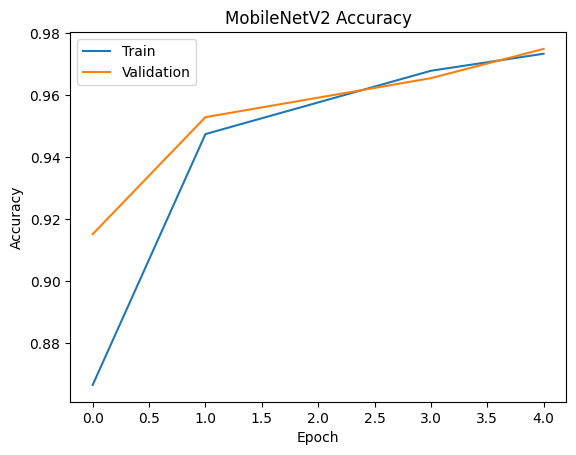

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

****
**14. Loss Graph**
****

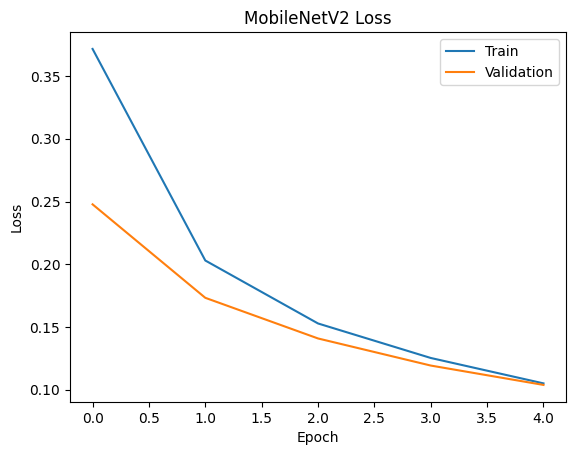

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('MobileNetV2 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

****
**15. Predict Emotion**
****

In [22]:
from google.colab import files

uploaded = files.upload()

Saving 00a99d2c-01d9-454e-9f7d-26bc066282fc.webp to 00a99d2c-01d9-454e-9f7d-26bc066282fc.webp


In [24]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

print("Raw Prediction:", prediction[0][0])
print("Classes:", train_ds.class_names)

if prediction[0][0] < 0.5:
    print("😊 Happy")
else:
    print("😔 Sad")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Raw Prediction: 0.9814783
Classes: ['happy', 'sad']
😔 Sad
